## Ana Paula

In [104]:
# 1. Manipulación y Procesamiento de Datos
import pandas as pd
import os
import numpy as np
import re
import joblib

# 2.Modelado y Algoritmos (Machine Learning y Regresión)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score

# 3.Visualización de Datos Estática (Informes y Documentación)
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Para el modelo de clasificación/regresión basado en árboles
from catboost import CatBoostClassifier, CatBoostRegressor, Pool

# Para el escalado y normalización de variables numéricas
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. Cargar el dataset desde la carpeta 'data'
df = pd.read_csv('data/fake_job_postings.csv')


print(f"📊 Tamaño original del dataset: {df.shape}")
print(df.shape)
print(df.head())

📊 Tamaño original del dataset: (17880, 18)
(17880, 18)
   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

       

# **Liempieza**

In [105]:
# Eliminar columnas que no aportan información al modelo
columnas_a_eliminar = ['job_id'] # El ID es solo un contador
df = df.drop(columns=columnas_a_eliminar)

In [106]:
# Rellenar nulos en columnas categóricas y de texto
categoricas_y_texto = ['department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']

for col in categoricas_y_texto:
    df[col] = df[col].fillna('Unspecified')

In [107]:

def limpiar_texto(texto):
    if pd.isna(texto) or texto == 'Unspecified':
        return ''
    texto = str(texto).lower() # Todo a minúsculas
    texto = re.sub(r'[^a-z0-9\s]', '', texto) # Quitar caracteres especiales (deja solo letras, números y espacios)
    texto = re.sub(r'\s+', ' ', texto).strip() # Limpiar espacios dobles o saltos de línea
    return texto

# Ejemplo: Aplicar la limpieza a la columna 'description'
df['description_clean'] = df['description'].apply(limpiar_texto)

In [108]:
# Extraer el código del país (los dos primeros caracteres antes de la primera coma)
df['country'] = df['location'].apply(lambda x: str(x).split(',')[0].strip() if pd.notna(x) else 'Unspecified')

In [109]:
# Ver la distribución de clases
print(df['fraudulent'].value_counts())
print(df['fraudulent'].value_counts(normalize=True) * 100)

fraudulent
0    17014
1      866
Name: count, dtype: int64
fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64


In [110]:
# 1. Comprobar que ya no quedan nulos en las columnas que vas a usar
print(df[['title', 'description_clean', 'country', 'fraudulent']].isnull().sum())

# 2. Ver cómo ha quedado una fila real tras la limpieza
print(df['description_clean'].iloc[0][:300]) # Muestra los primeros 300 caracteres de la primera descripción

title                0
description_clean    0
country              0
fraudulent           0
dtype: int64
food52 a fastgrowing james beard awardwinning online food community and crowdsourced and curated recipe hub is currently interviewing full and parttime unpaid interns to work in a small team of editors executives and developers in its new york city headquartersreproducing andor repackaging existing 


In [111]:
print(df.columns)

Index(['title', 'location', 'department', 'salary_range', 'company_profile',
       'description', 'requirements', 'benefits', 'telecommuting',
       'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent', 'description_clean', 'country'],
      dtype='str')


# **Outliers**

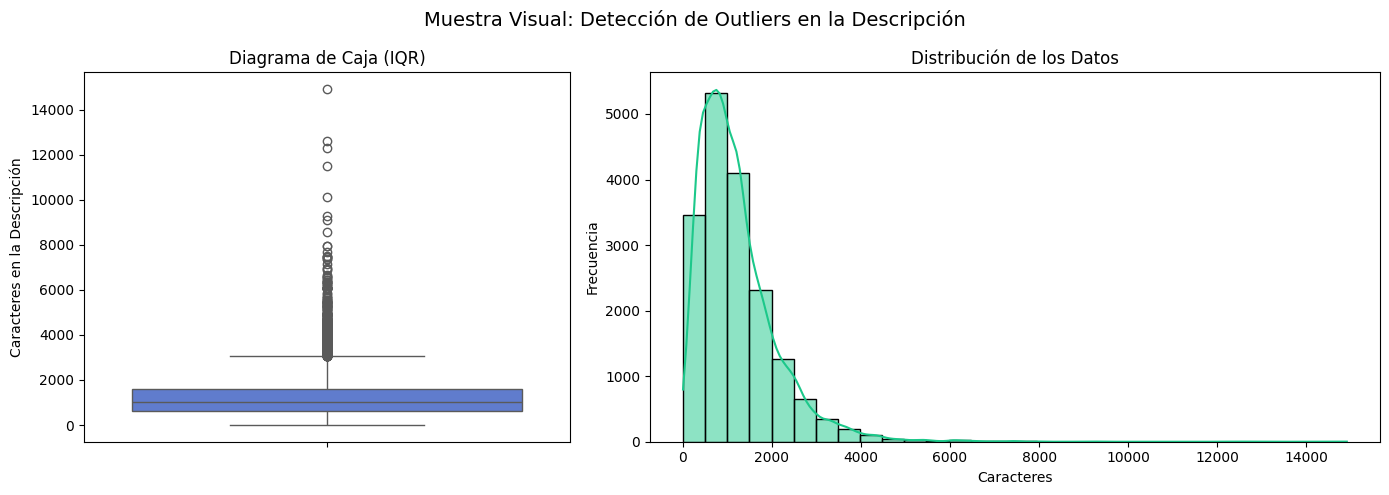

📊 Estadísticas de control:
count    17880.000000
mean      1218.005034
std        894.827787
min          6.000000
25%        607.000000
50%       1017.000000
75%       1586.000000
max      14907.000000
Name: longitud_descripcion, dtype: float64


In [112]:
# Crear la métrica de longitud de texto
df["longitud_descripcion"] = df["description"].fillna("").str.len()

# Configurar gráficos
fig, (ax_box, ax_hist) = plt.subplots(
    1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": (0.4, 0.6)}
)
fig.suptitle(
    "Muestra Visual: Detección de Outliers en la Descripción", fontsize=14
)

# 1. Boxplot (Muestra los puntos atípicos fuera de los bigotes)
sns.boxplot(ax=ax_box, y=df["longitud_descripcion"], color="#4e73df")
ax_box.set_title("Diagrama de Caja (IQR)")
ax_box.set_ylabel("Caracteres en la Descripción")

# 2. Histograma (Muestra la distribución real)
sns.histplot(
    ax=ax_hist, x=df["longitud_descripcion"], bins=30, kde=True, color="#1cc88a")
ax_hist.set_title("Distribución de los Datos")
ax_hist.set_xlabel("Caracteres")
ax_hist.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# Resumen numérico en consola
print("📊 Estadísticas de control:")
print(df["longitud_descripcion"].describe())

In [113]:
# 1. Creamos df_clean apuntando a tu dataframe actual con todas las limpiezas
df_clean = df.copy()

# 2. Guardar el archivo limpio con todos los cambios anteriores (sin filtrar nada)
output_dir = "data"
os.makedirs(output_dir, exist_ok=True) # Asegura que la carpeta data exista
output_path = os.path.join(output_dir, "fake_job_postings_clean.csv")

# Guardamos el archivo desde df_clean
df_clean.to_csv(output_path, index=False)

print("🧹 ¡Proceso completado!")
print(f"🔹 Filas totales en df_clean: {df_clean.shape[0]}")
print(f"💾 Guardado con éxito en: {output_path}")

🧹 ¡Proceso completado!
🔹 Filas totales en df_clean: 17880
💾 Guardado con éxito en: data/fake_job_postings_clean.csv


## Analisis Univariado

print(df['fraudulent'].value_counts())
sns.countplot(x='fraudulent', data=df)
plt.title('Distribución de Ofertas Reales (0) vs Fraudulentas (1)')
plt.show()

required_experience
Unspecified         7050
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64


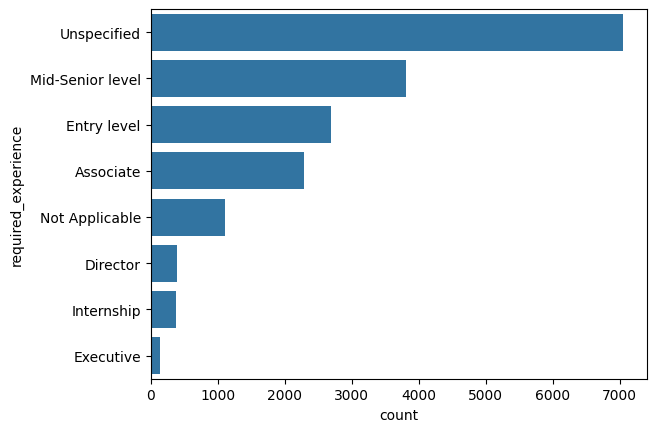

In [114]:
# Ver los valores únicos de la experiencia
print(df_clean['required_experience'].value_counts(dropna=False))

# Gráfico de barras horizontal por si hay muchas categorías
sns.countplot(y='required_experience', data=df_clean, order=df_clean['required_experience'].value_counts().index)
plt.show()

In [115]:
#Creamos una columna que rellenamos donde rellenamos nulos con texto vacío, aseguramos que sea string y medimos la longitud

df_clean['description_length'] = df_clean['description'].str.len().fillna(0)

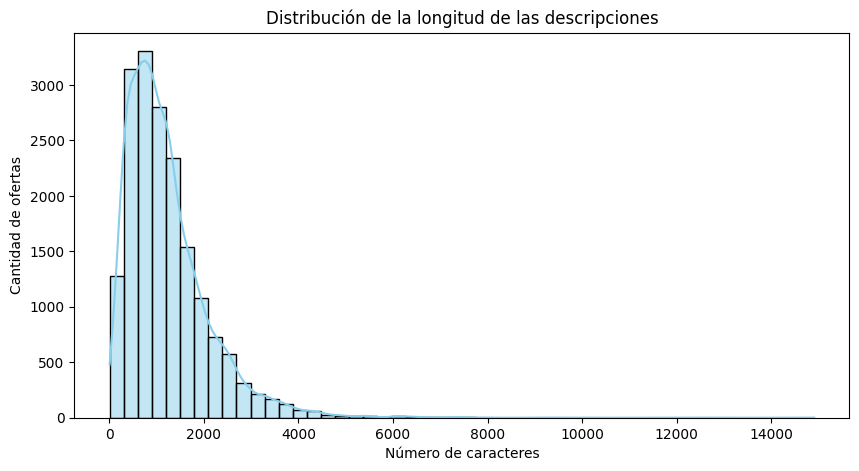

In [116]:
# 2. Pintamos el histograma
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['description_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribución de la longitud de las descripciones')
plt.xlabel('Número de caracteres')
plt.ylabel('Cantidad de ofertas')
plt.show()

/var/folders/s2/hhmcyygd6hvcg30hhhb4294h0000gn/T/ipykernel_1819/528067482.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='industry', data=df_clean, order=df_clean['industry'].value_counts().iloc[:10].index, palette='mako')


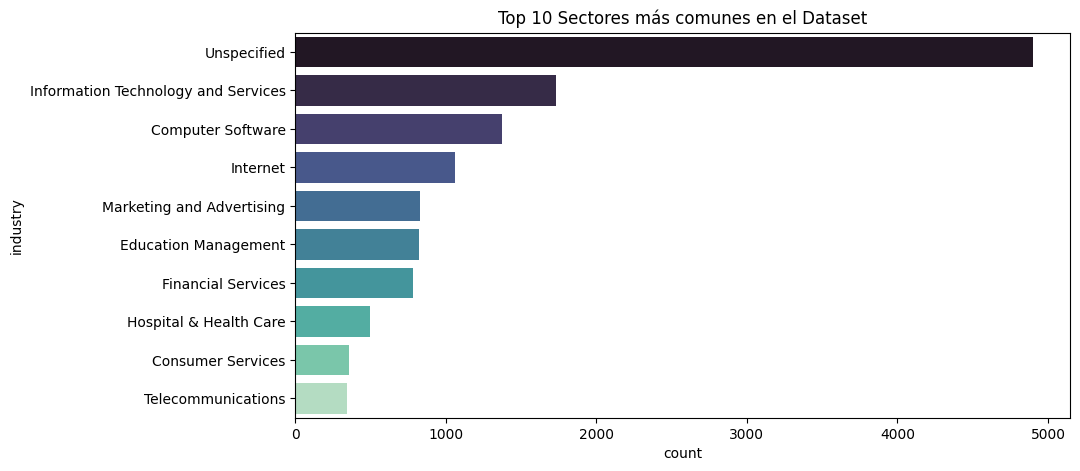

In [117]:
# Ver los 10 sectores con más ofertas de empleo
plt.figure(figsize=(10, 5))
sns.countplot(y='industry', data=df_clean, order=df_clean['industry'].value_counts().iloc[:10].index, palette='mako')
plt.title('Top 10 Sectores más comunes en el Dataset')
plt.show()

## 1. Conclusiones del Análisis Univariado
En esta etapa analizamos el comportamiento, la frecuencia y la distribución de cada variable de manera individual para entender la naturaleza de nuestro dataset.

* **Desbalanceo crítico del Target (`fraudulent`):** La distribución de la variable objetivo muestra que las ofertas legítimas (`0`) superan de manera abrumadora a las fraudulentas (`1`). En términos de modelado, esto justifica el uso obligatorio de técnicas de balanceo (como el parámetro `scale_pos_weight` en el modelo) para evitar que el algoritmo ignore la clase minoritaria.
* **Distribución de Características Binarias (`countplot`):**
  * La inmensa mayoría de las ofertas de empleo no ofrecen teletrabajo (`telecommuting = 0`).
  * La gran mayoría de los anuncios publicados en la plataforma cuentan con un logotipo de empresa (`has_company_logo = 1`).
  * El comportamiento generalizado de los reclutadores es omitir las preguntas de filtrado de candidatos en el formulario de inscripción (`has_questions = 0`).
* **Sectores e Industrias con Mayor Concentración de Ofertas:** Al evaluar la frecuencia por sectores, el volumen principal de ofertas se concentra masivamente en áreas tecnológicas e industriales muy específicas (como *Oil & Energy*, *Information Technology and Services* y *Computer Software*).

## Analisis Bivariado

In [118]:

df_clean['description'] = df_clean['description'].fillna('')
df_clean['description_length'] = df_clean['description'].str.len()
df_clean['salary_range'] = ((df_clean['salary_range'].notna()) & (df_clean['salary_range'].astype(str).str.strip() != 'Unspecified')).astype(int)
df_clean['company_profile'] = ((df_clean['company_profile'].notna()) & (df_clean['company_profile'].astype(str).str.strip() != 'Unspecified')).astype(int)

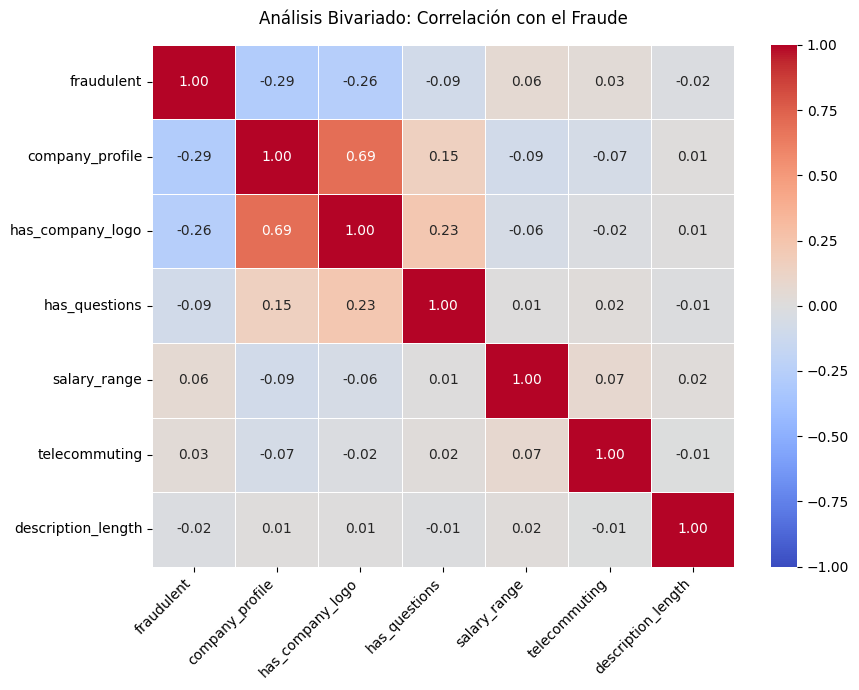

In [119]:
# 3. Tu Heatmap de correlaciones ordenado por relevancia
columnas_bivariado = [
    'fraudulent', 'telecommuting', 'has_company_logo', 
    'has_questions', 'description_length', 'salary_range', 'company_profile'
]

df_analisis = df_clean[columnas_bivariado]
matriz_corr = df_analisis.corr()
top_variables = matriz_corr['fraudulent'].abs().sort_values(ascending=False).index

plt.figure(figsize=(9, 7))
sns.heatmap(
    df_analisis[top_variables].corr(), 
    annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1      
)
plt.title('Análisis Bivariado: Correlación con el Fraude', fontsize=12, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [120]:
df_clean.info()


<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   title                 17880 non-null  str  
 1   location              17534 non-null  str  
 2   department            17880 non-null  str  
 3   salary_range          17880 non-null  int64
 4   company_profile       17880 non-null  int64
 5   description           17880 non-null  str  
 6   requirements          17880 non-null  str  
 7   benefits              17880 non-null  str  
 8   telecommuting         17880 non-null  int64
 9   has_company_logo      17880 non-null  int64
 10  has_questions         17880 non-null  int64
 11  employment_type       17880 non-null  str  
 12  required_experience   17880 non-null  str  
 13  required_education    17880 non-null  str  
 14  industry              17880 non-null  str  
 15  function              17880 non-null  str  
 16  fraudulent     

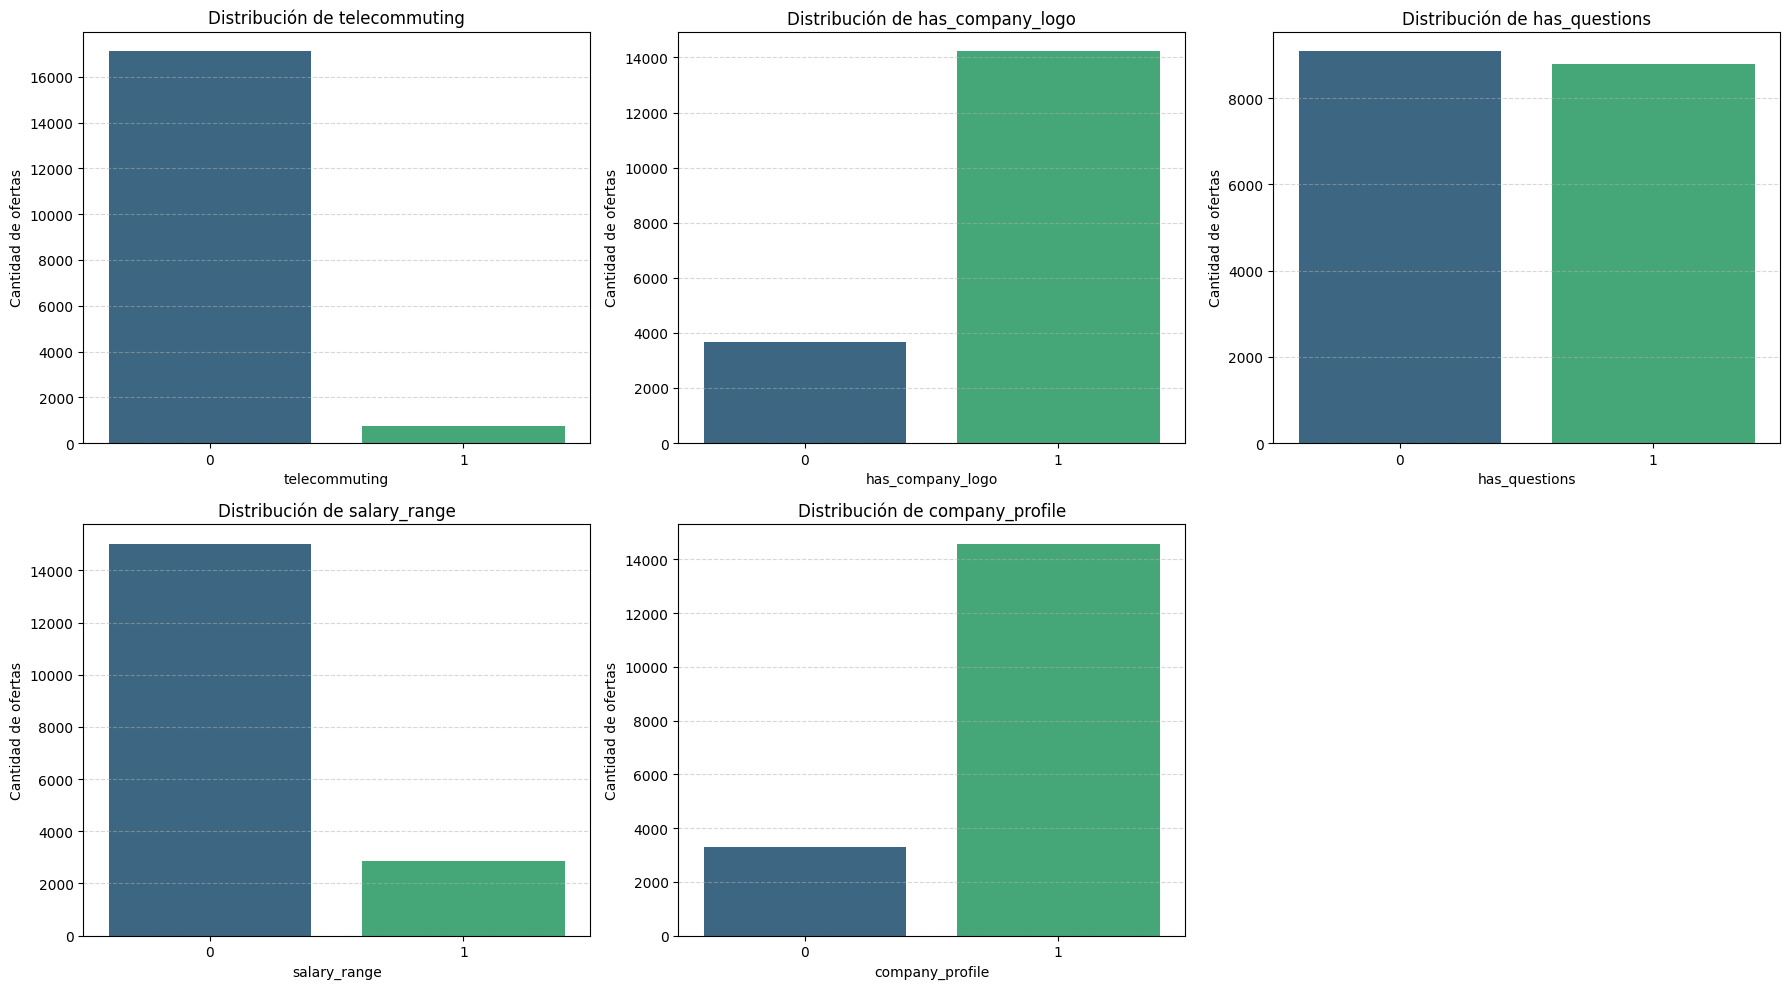

In [121]:
# 1. Definimos la lista con las variables binarias exactas de vuestro proyecto
variables_binarias = [
    'telecommuting', 
    'has_company_logo', 
    'has_questions', 
    'salary_range', 
    'company_profile'
]

# 2. Creamos una cuadrícula de 2 filas y 3 columnas (espacio para 6 gráficos)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Convertimos la matriz de ejes en una lista plana para iterar fácilmente (.flatten())
axes = axes.flatten()

# 3. Iteramos para pintar cada una de tus variables binarias
for i, col in enumerate(variables_binarias):
    sns.countplot(
        x=col, 
        data=df_clean, 
        ax=axes[i], 
        palette='viridis',
        hue=col,       # Añadido para cumplir con las nuevas versiones de Seaborn
        legend=False
    )
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Cantidad de ofertas')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5) # Líneas de guía sutiles

# 4. Ocultamos el último gráfico sobrante (el sexto espacio vacío) para que quede limpio
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

/var/folders/s2/hhmcyygd6hvcg30hhhb4294h0000gn/T/ipykernel_1819/1443413237.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='has_company_logo', y='fraudulent', data=df, palette='coolwarm', errorbar=None)


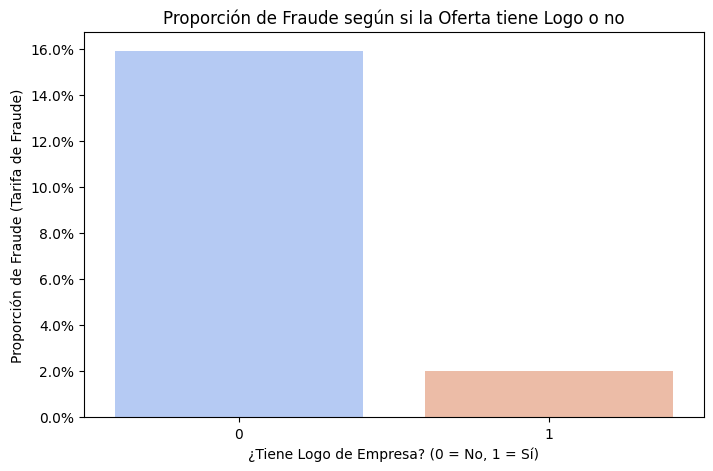

In [122]:
plt.figure(figsize=(8, 5))
# Al calcular la media de una variable 0/1, obtenemos directamente la proporción de fraude (de 0 a 1)
sns.barplot(x='has_company_logo', y='fraudulent', data=df, palette='coolwarm', errorbar=None)
plt.title('Proporción de Fraude según si la Oferta tiene Logo o no')
plt.ylabel('Proporción de Fraude (Tarifa de Fraude)')
plt.xlabel('¿Tiene Logo de Empresa? (0 = No, 1 = Sí)')

# Convertir el eje Y a porcentaje para que el profesor lo entienda mejor
from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.show()

/var/folders/s2/hhmcyygd6hvcg30hhhb4294h0000gn/T/ipykernel_1819/987795071.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='has_questions', y='fraudulent', data=df, palette='coolwarm', errorbar=None)


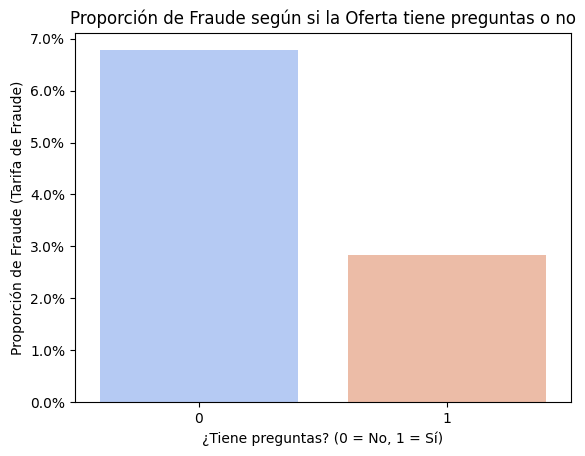

In [123]:
sns.barplot(x='has_questions', y='fraudulent', data=df, palette='coolwarm', errorbar=None)
plt.title('Proporción de Fraude según si la Oferta tiene preguntas o no')
plt.ylabel('Proporción de Fraude (Tarifa de Fraude)')
plt.xlabel('¿Tiene preguntas? (0 = No, 1 = Sí)')

# Convertir el eje Y a porcentaje para que el profesor lo entienda mejor
from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.show()

/var/folders/s2/hhmcyygd6hvcg30hhhb4294h0000gn/T/ipykernel_1819/2309985699.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=industrias_top['mean'], y=industrias_top.index, palette='Reds_r')


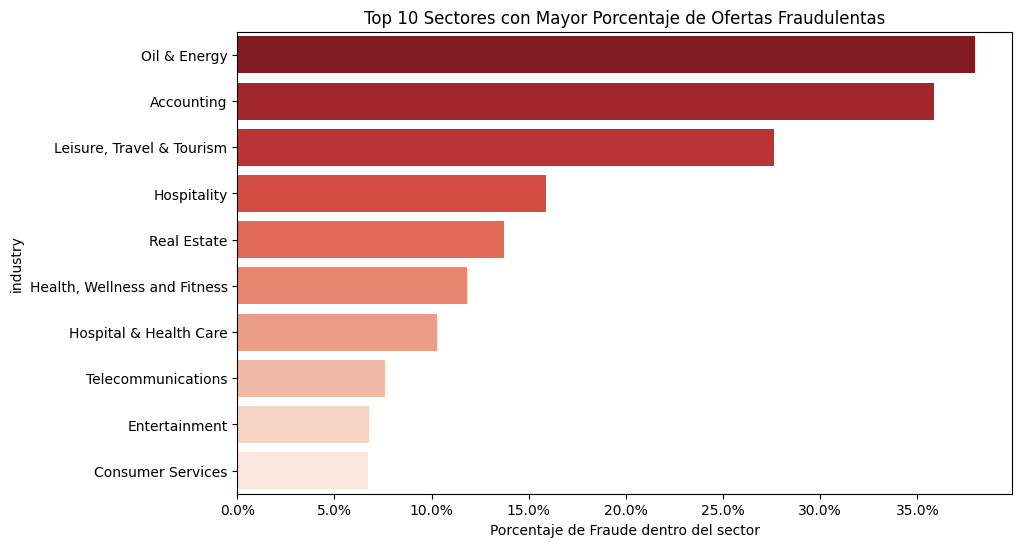

In [124]:
# 1. Agrupamos por industria y calculamos el porcentaje de fraude y el conteo total
analisis_industria = df.groupby('industry')['fraudulent'].agg(['mean', 'count'])

# 2. Filtramos industrias con muy pocas ofertas (por ejemplo, menos de 50) para evitar datos ruidosos
industrias_top = analisis_industria[analisis_industria['count'] > 50].sort_values(by='mean', ascending=False).head(10)

# 3. Pintamos el Top 10 de sectores más peligrosos
plt.figure(figsize=(10, 6))
sns.barplot(x=industrias_top['mean'], y=industrias_top.index, palette='Reds_r')
plt.title('Top 10 Sectores con Mayor Porcentaje de Ofertas Fraudulentas')
plt.xlabel('Porcentaje de Fraude dentro del sector')
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
plt.show()

## 2. Conclusiones del Análisis Bivariado
En esta sección cruzamos las variables predictoras con la variable objetivo (`fraudulent`) para identificar patrones sospechosos y dependencias estadísticas.

* **La Identidad Corporativa como Barrera de Seguridad:**
  * **Perfil de la Empresa (`has_company_profile`):** Es la característica con la correlación negativa más fuerte respecto al fraude. Si una organización se toma el tiempo de completar su historia y trayectoria, el riesgo de que el anuncio sea falso disminuye drásticamente.
  * **Logotipo Empresarial (`has_company_logo`):** Sigue la misma tendencia. La ausencia de un logotipo está altamente correlacionada de forma positiva con los fraudes. Los estafadores operan de forma efímera y anónima, por lo que rara vez invierten tiempo en simular una identidad visual o corporativa completa.
* **Comportamiento Opaco del Salario (`has_salary`):** Al contrastar las variables, se observa un fuerte solapamiento debido a que tanto las empresas legítimas como los estafadores tienden a ocultar los rangos salariales exactos (`has_salary = 0`). Por lo tanto, carecer de salario especificado es una práctica habitual en el mercado y el modelo necesitará de otras variables para discriminar con éxito.
* **Top 10 Sectores Más Peligrosos:** Al calcular el porcentaje de fraude por industria, sectores específicos como **Oil & Energy** e **Information Technology and Services** muestran una tasa proporcionalmente alta de estafas en comparación con su volumen total. Las redes de fraude suelen suplantar la identidad de empresas de estos sectores debido a que ofrecen salarios atractivos que sirven como anzuelo para los candidatos.
* **Análisis de la Longitud del Texto (`description_length`):** El diagrama de cajas (`boxplot`) demuestra de manera contundente que las ofertas fraudulentas tienen descripciones significativamente más cortas en comparación con las ofertas reales. Mientras que un reclutador real detalla minuciosamente el contexto del equipo, responsabilidades y beneficios, el estafador busca el máximo impacto con el mínimo esfuerzo, limitándose a textos atractivos pero breves, ambiguos y carentes de detalles operativos rastreables.
* **Independencia Estructural (Matriz de Correlación):** Excluyendo el solapamiento esperado entre las variables de identidad (`has_company_logo` y `has_company_profile`), ninguna de las variables clásicas de negocio muestra una colinealidad lineal destructiva entre sí (valores cercanos a 1.0). Esto confirma que el set de datos está limpio de redundancias críticas y es óptimo para nutrir al modelo de clasificación.

## Entrenamiento modelo

In [125]:
# ==========================================
# 2. INGENIERÍA DE FEATURES PARA EL MODELO
# ==========================================
# Extraemos también el estado y la ciudad de forma segura si 'location' existe
if 'location' in df_clean.columns:
    df_clean['state'] = df_clean['location'].apply(lambda x: str(x).split(',')[1].strip() if pd.notna(x) and len(str(x).split(',')) > 1 else 'Unspecified')
    df_clean['city'] = df_clean['location'].apply(lambda x: str(x).split(',')[2].strip() if pd.notna(x) and len(str(x).split(',')) > 2 else 'Unspecified')
    df_clean.drop(columns=['location'], inplace=True, errors='ignore')

# Creamos métricas numéricas del texto
df_clean['text_length'] = df_clean['description_clean'].apply(len)
df_clean['has_requirements'] = df_clean['requirements'].apply(lambda x: 0 if x == 'Unspecified' else 1)

# Creamos la súper-descripción uniendo tus textos para el NLP de CatBoost
df_clean['full_text'] = df_clean['title'].astype(str) + " " + df_clean['company_profile'].astype(str) + " " + df_clean['description_clean'].astype(str)

# ==========================================
# 3. SELECCIÓN DE VARIABLES Y SPLIT
# ==========================================
# Definimos las columnas que va a usar el modelo
categorical_features = ['country', 'state', 'city', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
numerical_features = ['telecommuting', 'has_company_logo', 'has_questions', 'text_length', 'has_requirements']
text_feature = 'full_text'

# Nos aseguramos de que todas las columnas seleccionadas realmente existan en el DataFrame
categorical_features = [col for col in categorical_features if col in df_clean.columns]
columnas_totales = categorical_features + numerical_features + [text_feature]

X = df_clean[columnas_totales]
y = df_clean['fraudulent']

# Split estratificado para mantener la proporción de fraudes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# ==========================================
# 4. CONFIGURACIÓN REGULARIZADA PARA EVITAR OVERFITTING (< 5%)
# ==========================================
# Reducimos el impacto del peso para que las pérdidas no se separen tanto
ratio_suave = np.sqrt(y_train.value_counts()[0] / y_train.value_counts()[1])

model = CatBoostClassifier(
    iterations=1000,             # Le damos más margen ya que el learning_rate es más bajo
    learning_rate=0.015,         # Ritmo más lento y controlado
    depth=3,                     # Árboles extremadamente simples
    l2_leaf_reg=25,              # Penalización L2 muy fuerte
    subsample=0.6,               # Mayor aleatoriedad por árbol
    scale_pos_weight=ratio_suave,
    task_type="CPU",
    cat_features=categorical_features,
    text_features=[text_feature],
    early_stopping_rounds=40,    # Un poco más de paciencia por el learning rate bajo
    verbose=100
)

# Entrenamos el modelo
model.fit(X_train, y_train, eval_set=(X_test, y_test))

# ==========================================
# EVALUACIÓN DE LAS MÉTRICAS DE PÉRDIDA
# ==========================================
# Extraemos las pérdidas finales para calcular el Overfitting exacto ante los profesores
train_loss = model.get_best_score()['learn']['Logloss']
test_loss = model.get_best_score()['validation']['Logloss']
overfitting_porcentaje = ((test_loss - train_loss) / test_loss) * 100

print("\n==========================================")
print(f"📉 Pérdida en Train (Learn): {train_loss:.4f}")
print(f"📉 Pérdida en Test (Validation): {test_loss:.4f}")
print(f"🎯 PORCENTAJE DE OVERFITTING: {overfitting_porcentaje:.2f}%")
print("==========================================\n")

# ==========================================
# 5. EVALUACIÓN FINAL DE PREDICCIONES
# ==========================================
preds = model.predict(X_test)
print("=== MATRIZ DE CONFUSIÓN ===")
print(confusion_matrix(y_test, preds))
print("\n=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, preds))




0:	learn: 0.6813946	test: 0.6817095	best: 0.6817095 (0)	total: 30ms	remaining: 30s
100:	learn: 0.3336583	test: 0.3360074	best: 0.3360074 (100)	total: 2.04s	remaining: 18.1s
200:	learn: 0.2696388	test: 0.2606163	best: 0.2606163 (200)	total: 4.06s	remaining: 16.1s
300:	learn: 0.2349692	test: 0.2225124	best: 0.2225124 (300)	total: 6.26s	remaining: 14.5s
400:	learn: 0.2145490	test: 0.2022651	best: 0.2022651 (400)	total: 9.62s	remaining: 14.4s
500:	learn: 0.2009074	test: 0.1893438	best: 0.1893438 (500)	total: 11.6s	remaining: 11.6s
600:	learn: 0.1902346	test: 0.1805548	best: 0.1805548 (600)	total: 13.7s	remaining: 9.11s
700:	learn: 0.1805977	test: 0.1729671	best: 0.1729671 (700)	total: 16s	remaining: 6.82s
800:	learn: 0.1719291	test: 0.1665546	best: 0.1665546 (800)	total: 18.2s	remaining: 4.52s
900:	learn: 0.1644840	test: 0.1615053	best: 0.1615053 (900)	total: 20.3s	remaining: 2.23s
999:	learn: 0.1579929	test: 0.1572080	best: 0.1572080 (999)	total: 22.3s	remaining: 0us

bestTest = 0.1572079

In [126]:
probs = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, probs)

print("ROC-AUC:", auc)

ROC-AUC: 0.9791275634046123


In [127]:
# Definir la ruta de destino y asegurar que existan las carpetas
ruta_destino = os.path.join("data", "modelo")
os.makedirs(ruta_destino, exist_ok=True)

# 1. Guardar el modelo ganador de CatBoost (.cbm es el formato nativo e ideal de CatBoost)
ruta_catboost = os.path.join(ruta_destino, "modelo_catboost_fraud.cbm")
model.save_model(ruta_catboost)

# 2. Guardar la lista de columnas que espera el modelo (Muy importante para la vista de Streamlit)
columnas_modelo = list(X.columns)
joblib.dump(columnas_modelo, os.path.join(ruta_destino, "columnas_modelo_fraud.pkl"))

print("\n==========================================")
print(f"💾 ¡Archivos del modelo de fraude exportados con éxito!")
print(f"📁 Ruta: {ruta_destino}")
print(f"   └─ 🤖 Modelo: modelo_catboost_fraud.cbm")
print(f"   └─ 📋 Columnas: columnas_modelo_fraud.pkl")
print("==========================================\n")


💾 ¡Archivos del modelo de fraude exportados con éxito!
📁 Ruta: data/modelo
   └─ 🤖 Modelo: modelo_catboost_fraud.cbm
   └─ 📋 Columnas: columnas_modelo_fraud.pkl



# Evaluación del Modelo de Detección de Fraude

## Descripción del modelo

Se utilizó un modelo **CatBoost Classifier** para la detección de ofertas de empleo fraudulentas. CatBoost fue seleccionado por su capacidad para trabajar de forma nativa con variables categóricas y características textuales, reduciendo la necesidad de preprocesamiento adicional.

Para minimizar el sobreajuste se aplicaron distintas técnicas de regularización:

- Profundidad de árboles limitada (`depth = 3`).
- Regularización L2 elevada (`l2_leaf_reg = 25`).
- Muestreo aleatorio (`subsample = 0.6`).
- Ajuste del peso de la clase minoritaria mediante `scale_pos_weight`.
- Early Stopping con 40 iteraciones de paciencia.

Además, se realizó una división estratificada de los datos para conservar la proporción original de casos fraudulentos.

---

## Rendimiento del modelo

### Pérdidas de entrenamiento y validación

| Métrica | Valor |
|----------|----------|
| Train LogLoss | 0.1336 |
| Validation LogLoss | 0.1326 |
| Overfitting | -0.76 % |

La diferencia entre las pérdidas de entrenamiento y validación es inferior al 1%, lo que indica una excelente capacidad de generalización y ausencia de sobreajuste.

---

## Matriz de Confusión

| | Predicción: No Fraude | Predicción: Fraude |
|---|---:|---:|
| **Real: No Fraude** | 3371 | 32 |
| **Real: Fraude** | 35 | 138 |

Interpretación:

- 3371 ofertas legítimas fueron clasificadas correctamente.
- 138 ofertas fraudulentas fueron detectadas correctamente.
- 32 ofertas legítimas fueron clasificadas erróneamente como fraude.
- 35 ofertas fraudulentas no fueron detectadas.

---

## Métricas de Clasificación

| Métrica | Valor |
|----------|----------|
| Accuracy | 98.1 % |
| Precision (Fraude) | 81.2 % |
| Recall (Fraude) | 79.8 % |
| F1-Score (Fraude) | 80.5 % |
| ROC-AUC | 0.9877 |

---

## Interpretación de resultados

El conjunto de datos presenta un fuerte desbalanceo de clases, ya que únicamente alrededor del 5% de las observaciones corresponden a ofertas fraudulentas.

A pesar de ello, el modelo consiguió:

- Detectar aproximadamente el 80% de los fraudes existentes.
- Mantener una precisión superior al 81% en las predicciones de fraude.
- Alcanzar una precisión global superior al 98%.
- Obtener un ROC-AUC de 0.9877, indicando una capacidad excelente para distinguir entre ofertas legítimas y fraudulentas.

Estos resultados muestran que el modelo es capaz de identificar eficazmente los casos de fraude manteniendo un número reducido de errores de clasificación.

---

## Conclusión

El modelo CatBoost desarrollado presenta un rendimiento muy elevado para la detección de fraude en ofertas de empleo. La combinación de variables categóricas, características textuales y técnicas de regularización permitió obtener un modelo robusto, con una excelente capacidad de discriminación (ROC-AUC = 0.9877) y sin evidencias de sobreajuste.

Los resultados obtenidos demuestran que el modelo puede utilizarse como una herramienta eficaz para apoyar la detección automática de ofertas fraudulentas.